# Coincidencia por plantilla

**Duración estimada:** 50 minutos

## Objetivo

En este cuaderno vas a ubicar una plantilla dentro de una imagen más grande. El objetivo es entender, paso a paso, cómo funciona `cv2.matchTemplate()`.


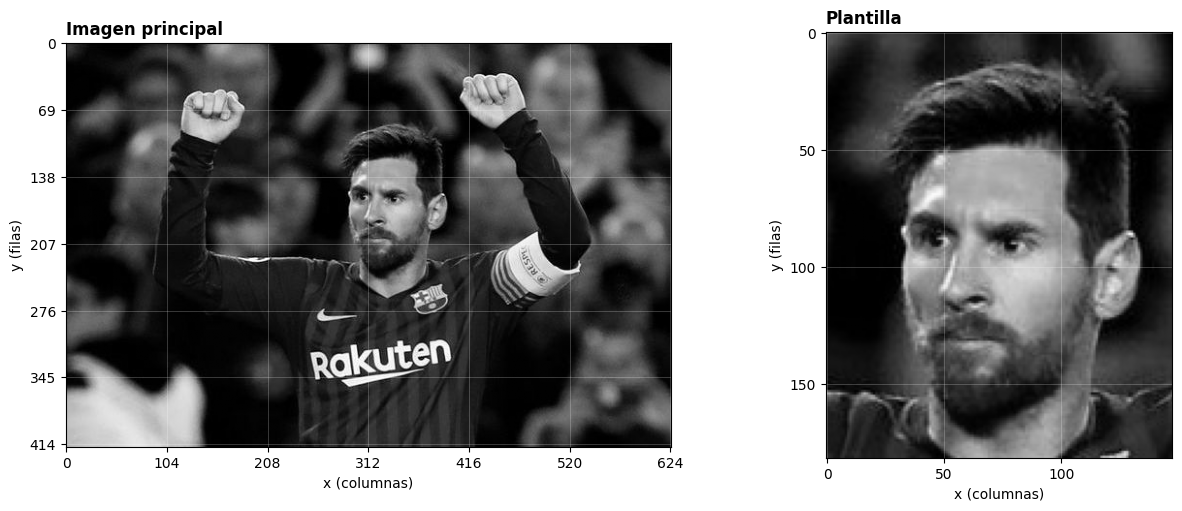

Forma de la imagen principal: (417, 625)
Forma de la plantilla: (182, 148)


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()

imagen_principal_gris = cv2.imread(str(CARPETA_IMAGENES / "messi.jpg"), cv2.IMREAD_GRAYSCALE)
plantilla_gris = cv2.imread(str(CARPETA_IMAGENES / "messi_template.jpg"), cv2.IMREAD_GRAYSCALE)

mostrar_varias_imagenes(
    [imagen_principal_gris, plantilla_gris],
    ["Imagen principal", "Plantilla"],
    ["gray", "gray"],
    tamano=(13, 5),
)

print("Forma de la imagen principal:", imagen_principal_gris.shape)
print("Forma de la plantilla:", plantilla_gris.shape)


## 1. Buscar una región parecida

`matchTemplate()` recorre la imagen principal y compara, posición por posición, qué tan parecida es cada zona a la plantilla dada. No reconoce “rostros” ni “jugadores” como concepto: compara patrones de intensidades.


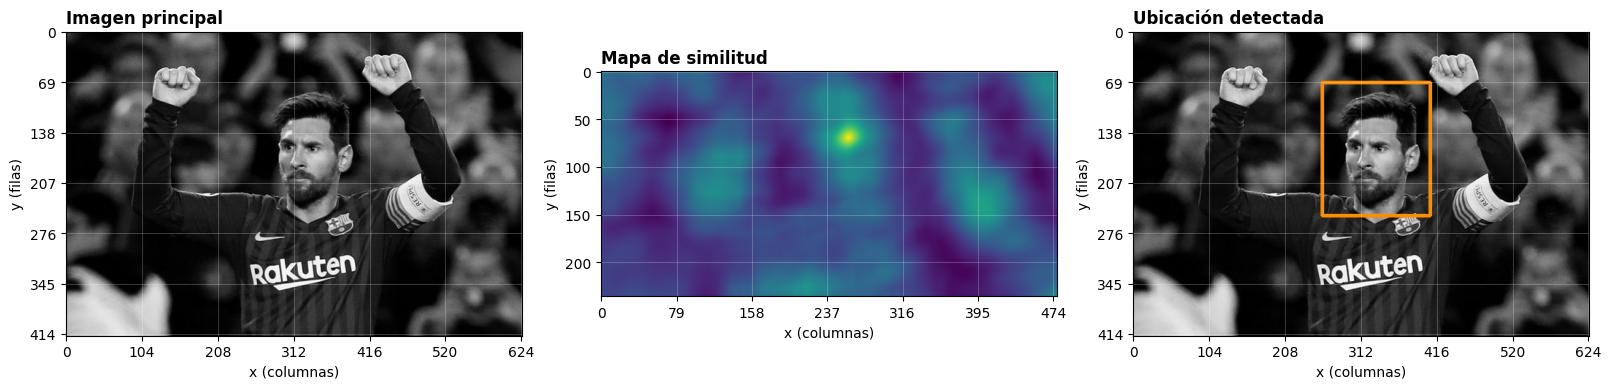

Puntaje máximo: 0.9996
Esquina superior izquierda detectada: (259, 70)


In [2]:
mapa_de_similitud = cv2.matchTemplate(imagen_principal_gris, plantilla_gris, cv2.TM_CCOEFF_NORMED)
_, puntaje_maximo, _, esquina_superior = cv2.minMaxLoc(mapa_de_similitud)

alto_plantilla, ancho_plantilla = plantilla_gris.shape
esquina_inferior = (esquina_superior[0] + ancho_plantilla, esquina_superior[1] + alto_plantilla)

imagen_detectada = cv2.cvtColor(imagen_principal_gris, cv2.COLOR_GRAY2RGB)
cv2.rectangle(imagen_detectada, esquina_superior, esquina_inferior, (255, 140, 0), 3)

mostrar_varias_imagenes(
    [imagen_principal_gris, mapa_de_similitud, imagen_detectada],
    ["Imagen principal", "Mapa de similitud", "Ubicación detectada"],
    ["gray", "viridis", None],
    tamano=(16, 5),
)

print(f"Puntaje máximo: {puntaje_maximo:.4f}")
print("Esquina superior izquierda detectada:", esquina_superior)


In [3]:
metodos = {
    "TM_CCOEFF_NORMED": cv2.TM_CCOEFF_NORMED,
    "TM_SQDIFF_NORMED": cv2.TM_SQDIFF_NORMED,
}

for nombre_metodo, metodo in metodos.items():
    mapa = cv2.matchTemplate(imagen_principal_gris, plantilla_gris, metodo)
    valor_minimo, valor_maximo, ubicacion_minima, ubicacion_maxima = cv2.minMaxLoc(mapa)

    if nombre_metodo == "TM_SQDIFF_NORMED":
        mejor_ubicacion = ubicacion_minima
        mejor_puntaje = valor_minimo
        criterio = "menor puntaje"
    else:
        mejor_ubicacion = ubicacion_maxima
        mejor_puntaje = valor_maximo
        criterio = "mayor puntaje"

    print(nombre_metodo)
    print(f"  Criterio de lectura: {criterio}")
    print(f"  Mejor ubicación: {mejor_ubicacion}")
    print(f"  Puntaje asociado: {mejor_puntaje:.4f}")


TM_CCOEFF_NORMED
  Criterio de lectura: mayor puntaje
  Mejor ubicación: (259, 70)
  Puntaje asociado: 0.9996
TM_SQDIFF_NORMED
  Criterio de lectura: menor puntaje
  Mejor ubicación: (259, 70)
  Puntaje asociado: 0.0003


## Cierre

Esta técnica es muy útil cuando el objeto mantiene una apariencia parecida a la plantilla. Si cambia mucho de escala, se rota o queda parcialmente tapado, hace falta un enfoque distinto.
